# Projeto Completo de Data Science em R

*Machine Learning - Ciencia de Dados*

**Dataset:** German Credit Data (UCI)
**Pacotes:** ggplot2, dplyr, ranger, yardstick, rsample

**Pipeline:** Dados -> Split -> Limpeza -> Treino -> Teste

## 1. Carregar Bibliotecas

In [2]:
# tidyverse NAO esta disponivel - usar pacotes individualmente
library(ggplot2)
library(dplyr)
library(tidyr)
library(ranger)
library(yardstick)
library(rsample)

cat("Bibliotecas carregadas!")

Warning message:
“pacote ‘ggplot2’ foi compilado no R versão 4.5.3”
Warning message:
“pacote ‘dplyr’ foi compilado no R versão 4.5.3”

Anexando pacote: ‘dplyr’


Os seguintes objetos são mascarados por ‘package:stats’:

    filter, lag


Os seguintes objetos são mascarados por ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“pacote ‘tidyr’ foi compilado no R versão 4.5.2”
Warning message:
“pacote ‘ranger’ foi compilado no R versão 4.5.2”
Warning message:
“pacote ‘yardstick’ foi compilado no R versão 4.5.3”
Warning message:
“pacote ‘rsample’ foi compilado no R versão 4.5.2”


Bibliotecas carregadas!

# German Credit Data (UCI)

Fonte: https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data

## 📊 Visão Geral

O dataset **German Credit** é amplamente utilizado para problemas de **classificação de risco de crédito**.  
Cada linha representa um cliente que solicitou crédito em um banco, e o objetivo é prever se ele é um **bom ou mau pagador**.

- Instâncias: 1000
- Atributos: 20 (features) + 1 variável alvo
- Tipos: categóricos e numéricos
- Tarefa: classificação binária
- Classes:
  - 1 → Bom crédito
  - 2 → Mau crédito :contentReference[oaicite:0]{index=0}

---

## 📦 Estrutura dos Dados

O arquivo `german.data` não possui cabeçalho e usa códigos simbólicos (ex: A11, A34, etc.), exigindo mapeamento.

### Variáveis (interpretadas)

1. Status da conta corrente  
2. Duração do crédito (meses)  
3. Histórico de crédito  
4. Propósito do crédito  
5. Valor do crédito  
6. Conta poupança  
7. Tempo de emprego atual  
8. Taxa de parcela (% da renda)  
9. Status pessoal e sexo  
10. Outros devedores / fiadores  
11. Tempo de residência  
12. Tipo de propriedade  
13. Idade  
14. Outros planos de pagamento  
15. Tipo de moradia  
16. Número de créditos existentes  
17. Tipo de trabalho  
18. Número de dependentes  
19. Telefone  
20. Trabalhador estrangeiro  

Variável alvo:
- Classificação de risco de crédito (bom ou ruim) :contentReference[oaicite:1]{index=1}

---

## 🧩 Tipos de Atributos

- **Categóricos**: status da conta, histórico, propósito, emprego, etc.
- **Numéricos**: idade, duração, valor do crédito

Alguns atributos categóricos são codificados com identificadores como:
- A11, A12 → categorias de conta
- A30–A34 → histórico de crédito

---

## ⚠️ Particularidades

- Não possui valores ausentes :contentReference[oaicite:2]{index=2}  
- Usa codificação simbólica (não legível diretamente)
- Existe uma versão numérica (`german.data-numeric`)
- Possui **matriz de custo** onde erros têm pesos diferentes:

| Real \ Predito | Bom | Ruim |
|---------------|-----|------|
| Bom           | 0   | 1    |
| Ruim          | 5   | 0    |

Erro mais grave: classificar um mau cliente como bom :contentReference[oaicite:3]{index=3}

---

## 🧠 Aplicações

- Credit scoring
- Avaliação de risco financeiro
- Modelos de classificação (Logistic Regression, Random Forest, etc.)
- Estudos de fairness e viés em ML

---

## 📌 Observações

- Dataset clássico de benchmarking em machine learning
- Bastante usado em cursos e pesquisas
- Requer pré-processamento cuidadoso (principalmente encoding)

---

## 2. Carregar Dados (German Credit - UCI)

In [3]:
# URL do dataset German Credit Data
url <- "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

# Nomes das colunas
col_names <- c("Status", "Duration", "Credit_history", "Purpose", "Amount",
               "Savings", "Employment", "Installment_rate", "Personal", "Others",
               "Residence", "Property", "Age", "Installment_plans", "Housing",
               "Existing_credits", "Job", "Liable_population", "Telephone", "Foreign", "Target")

# Carregar dados
dados <- read.table(url, col.names = col_names, stringsAsFactors = TRUE)

# Converter target: 1=bom (0), 2=mau (1) - e converter para factor!
dados$Target <- ifelse(dados$Target == 1, 0, 1)
dados$Target <- factor(dados$Target)  # IMPORTANT: factor para yardstick

cat("Dataset carregado:", nrow(dados), "observacoes", ncol(dados), "colunas\n")
str(dados$Target)

Dataset carregado: 1000 observacoes 21 colunas
 Factor w/ 2 levels "0","1": 1 2 1 1 2 1 1 1 1 2 ...


## 3. Train/Test Split (ANTES de qualquer transformacao!)

⚠️ **IMPORTANTE:** O split vem SEMPRE antes de qualquer pre-processamento!

Isso evita **DATA LEAKAGE** - quando informacao do teste vaza para o treino.

In [12]:
# Proporção inicial

table(dados$Target)
table(dados$Target) |> prop.table()


  0   1 
700 300 


  0   1 
0.7 0.3 

In [ ]:
set.seed(42)  # Reprodutibilidade

data_split <- initial_split(dados, prop = 0.8, strata = Target)
treino <- training(data_split)
teste <- testing(data_split)

cat("Treino:", nrow(treino), "observacoes\n")
cat("Teste:", nrow(teste), "observacoes\n")

# Verificar proporcao do target em cada conjunto
cat("\nQuantidade no treino:\n")
table(treino$Target)
table(treino$Target) |> prop.table()

cat("\nQuantidade no teste:\n")
table(teste$Target)
table(teste$Target) |> prop.table()

Treino: 800 observacoes
Teste: 200 observacoes

Quantidade no treino:



  0   1 
560 240 


  0   1 
0.7 0.3 


Quantidade no teste:



  0   1 
140  60 


  0   1 
0.7 0.3 

## 4. Limpeza (NO TREINO SOMENTE!)

⚠️ **DATA LEAKAGE:** Apenas o treino e usado para calcular estatisticas!

O teste permanece intocado até a avaliacao final.

In [4]:
# Verificar missing values
cat("Missing values no treino:", sum(is.na(treino)), "\n")
cat("Missing values no teste:", sum(is.na(teste)), "\n")

# O German Credit Data (UCI) nao tem missing values
# Se houvesse, tratar com mediana do TREINO somente
if (sum(is.na(treino)) > 0) {
  treino <- treino %>%
    mutate(across(where(is.numeric), ~replace_na(.x, median(.x, na.rm = TRUE))))
  teste <- teste %>%
    mutate(across(where(is.numeric), ~replace_na(.x, median(.x, na.rm = TRUE))))
  cat("Missing values tratados com mediana do treino\n")
} else {
  cat("Nenhum missing value encontrado - dados limpos!\n")
}

Missing values no treino: 0 


Missing values no teste: 0 


Nenhum missing value encontrado - dados limpos!


## 5. Feature Engineering (NO TREINO SOMENTE!)

In [5]:
# Converter variaveis categoricas para factor
treino <- treino %>%
  mutate(across(where(is.character), as.factor))

teste <- teste %>%
  mutate(across(where(is.character), as.factor))

# Verificar estrutura
glimpse(treino)

Rows: 800
Columns: 21
$ Status            <fct> A14, A11, A14, A12, A14, A11, A14, A11, A11, A12, A1…
$ Duration          <int> 12, 42, 12, 12, 24, 30, 24, 6, 10, 12, 10, 6, 6, 12,…
$ Credit_history    <fct> A34, A32, A32, A32, A34, A30, A32, A32, A34, A34, A3…
$ Purpose           <fct> A46, A42, A43, A43, A43, A49, A43, A43, A40, A41, A4…
$ Amount            <int> 2096, 7882, 3059, 1567, 2424, 8072, 3430, 2647, 2241…
$ Savings           <fct> A61, A61, A64, A61, A65, A65, A63, A63, A61, A62, A6…
$ Employment        <fct> A74, A74, A74, A73, A75, A72, A75, A73, A72, A72, A7…
$ Installment_rate  <int> 2, 2, 2, 1, 4, 2, 3, 2, 1, 3, 2, 1, 4, 3, 3, 3, 2, 2…
$ Personal          <fct> A93, A93, A91, A92, A93, A93, A93, A93, A93, A93, A9…
$ Others            <fct> A101, A103, A101, A101, A101, A101, A101, A101, A101…
$ Residence         <int> 3, 4, 4, 1, 4, 3, 2, 3, 3, 4, 1, 2, 4, 3, 2, 3, 2, 2…
$ Property          <fct> A121, A122, A121, A123, A122, A123, A123, A121, A121…
$ Age             

## 6. Validacao Cruzada (k-fold)

In [ ]:
# 5-fold cross-validation
set.seed(42)
cv <- vfold_cv(treino, v = 5, strata = Target)
head(cv)

cat("\nCada linha = 1 fold\n")
cat("Na avaliacao do fold: 80% treino -> fit, 20% -> validacao\n")
cat("A media das 5 folds = score mais estavel\n")


Cada linha = 1 fold
Na avaliacao do fold: 80% treino -> fit, 20% -> validacao
A media das 5 folds = score mais estavel


In [21]:
head(analysis(cv$splits[[1]]))  # fold 1 treino
head(analysis(cv$splits[[2]]))  # fold 2 treino

head(assessment(cv$splits[[1]]))  # fold 1 validacao
head(assessment(cv$splits[[2]]))  # fold 2 validacao


,Status,Duration,Credit_history,Purpose,Amount,Savings,Employment,Installment_rate,Personal,Others,⋯,Property,Age,Installment_plans,Housing,Existing_credits,Job,Liable_population,Telephone,Foreign,Target
,<fct>,<int>,<fct>,<fct>,<int>,<fct>,<fct>,<int>,<fct>,<fct>,⋯,<fct>,<int>,<fct>,<fct>,<int>,<fct>,<int>,<fct>,<fct>,<fct>
1,A11,42,A32,A42,7882,A61,A74,2,A93,A103,⋯,A122,45,A143,A153,1,A173,2,A191,A201,0
2,A14,12,A32,A43,3059,A64,A74,2,A91,A101,⋯,A121,61,A143,A152,1,A172,1,A191,A201,0
3,A12,12,A32,A43,1567,A61,A73,1,A92,A101,⋯,A123,22,A143,A152,1,A173,1,A192,A201,0
4,A11,30,A30,A49,8072,A65,A72,2,A93,A101,⋯,A123,25,A141,A152,3,A173,1,A191,A201,0
5,A14,24,A32,A43,3430,A63,A75,3,A93,A101,⋯,A123,31,A143,A152,1,A173,2,A192,A201,0
6,A11,6,A32,A43,2647,A63,A73,2,A93,A101,⋯,A121,44,A143,A151,1,A173,2,A191,A201,0


,Status,Duration,Credit_history,Purpose,Amount,Savings,Employment,Installment_rate,Personal,Others,⋯,Property,Age,Installment_plans,Housing,Existing_credits,Job,Liable_population,Telephone,Foreign,Target
,<fct>,<int>,<fct>,<fct>,<int>,<fct>,<fct>,<int>,<fct>,<fct>,⋯,<fct>,<int>,<fct>,<fct>,<int>,<fct>,<int>,<fct>,<fct>,<fct>
1,A14,12,A34,A46,2096,A61,A74,2,A93,A101,⋯,A121,49,A143,A152,1,A172,2,A191,A201,0
2,A11,42,A32,A42,7882,A61,A74,2,A93,A103,⋯,A122,45,A143,A153,1,A173,2,A191,A201,0
3,A14,12,A32,A43,3059,A64,A74,2,A91,A101,⋯,A121,61,A143,A152,1,A172,1,A191,A201,0
4,A12,12,A32,A43,1567,A61,A73,1,A92,A101,⋯,A123,22,A143,A152,1,A173,1,A192,A201,0
5,A14,24,A34,A43,2424,A65,A75,4,A93,A101,⋯,A122,53,A143,A152,2,A173,1,A191,A201,0
6,A11,30,A30,A49,8072,A65,A72,2,A93,A101,⋯,A123,25,A141,A152,3,A173,1,A191,A201,0


,Status,Duration,Credit_history,Purpose,Amount,Savings,Employment,Installment_rate,Personal,Others,⋯,Property,Age,Installment_plans,Housing,Existing_credits,Job,Liable_population,Telephone,Foreign,Target
,<fct>,<int>,<fct>,<fct>,<int>,<fct>,<fct>,<int>,<fct>,<fct>,⋯,<fct>,<int>,<fct>,<fct>,<int>,<fct>,<int>,<fct>,<fct>,<fct>
1,A14,12,A34,A46,2096,A61,A74,2,A93,A101,⋯,A121,49,A143,A152,1,A172,2,A191,A201,0
2,A14,24,A34,A43,2424,A65,A75,4,A93,A101,⋯,A122,53,A143,A152,2,A173,1,A191,A201,0
3,A12,12,A34,A41,1804,A62,A72,3,A93,A101,⋯,A122,44,A143,A152,1,A173,1,A191,A201,0
4,A13,12,A32,A42,1474,A61,A72,4,A92,A101,⋯,A122,33,A141,A152,1,A174,1,A192,A201,0
5,A12,18,A33,A45,6204,A61,A73,2,A93,A101,⋯,A121,44,A143,A152,1,A172,2,A192,A201,0
6,A14,11,A34,A40,7228,A61,A73,1,A93,A101,⋯,A122,39,A143,A152,2,A172,1,A191,A201,0


,Status,Duration,Credit_history,Purpose,Amount,Savings,Employment,Installment_rate,Personal,Others,⋯,Property,Age,Installment_plans,Housing,Existing_credits,Job,Liable_population,Telephone,Foreign,Target
,<fct>,<int>,<fct>,<fct>,<int>,<fct>,<fct>,<int>,<fct>,<fct>,⋯,<fct>,<int>,<fct>,<fct>,<int>,<fct>,<int>,<fct>,<fct>,<fct>
1,A11,6,A32,A42,1374,A61,A73,1,A93,A101,⋯,A121,36,A141,A152,1,A172,1,A192,A201,0
2,A13,12,A31,A43,409,A64,A73,3,A92,A101,⋯,A121,42,A143,A151,2,A173,1,A191,A201,0
3,A12,18,A32,A49,1913,A64,A72,3,A94,A101,⋯,A121,36,A141,A152,1,A173,1,A192,A201,0
4,A11,24,A32,A42,4020,A61,A73,2,A93,A101,⋯,A123,27,A142,A152,1,A173,1,A191,A201,0
5,A13,10,A32,A44,1225,A61,A73,2,A93,A101,⋯,A123,37,A143,A152,1,A173,1,A192,A201,0
6,A11,30,A34,A41,6187,A62,A74,1,A94,A101,⋯,A123,24,A143,A151,2,A173,1,A191,A201,0


## 6.1 Context: RandomForest (Breiman 2001)

**Contexto Histórico:**
- Paper de Leo Breiman (2001): "Random Forests"
- Baseado em dois pilares: **bagging** + **random feature selection**
- Um dos primeiros algoritmos de **ensemble**

**Por que é o padrão de comparação?**
- Robusto: funciona bem "out of the box"
- Não precisa de muito tuning
- Combina poder preditivo com interpretabilidade
- Frequentemente usado como **baseline** em competitions (Kaggle, etc.)
- Novas técnicas precisam "bater" o RF para provar valor

### ⚠️ Limitações Importantes

**Não extrapola!** — Só prevê dentro do range dos dados de treino.
Se treino tem Age 20-60, **não consegue prever Age=80**.

Isso vale para **TODOS** os algoritmos (exceto alguns modelos paramétricos).

**Exemplo prático:**
- treino: Amount 1000-50000
- test: Amount 80000 → predictions serão ruins!

In [22]:
# Exemplo: RF não extrapola
# Se seus dados de treino têm Amount de 1000 a 50000,
# o modelo NÃO consegue prever bem valores como 80000 ou 100000

# Isso é uma limitação fundamental de RandomForest (e de quase todos os algoritmos)
# Apenas alguns modelos paramétricos conseguem extrapolar

## 7. Treino do Modelo (RandomForest com ranger)

In [37]:
# Treinar modelo RandomForest
modelo <- ranger(
  formula = Target ~ .,
  data = treino,
  num.trees = 100,
  importance = "impurity",
  probability = TRUE,
  seed = 42
)

cat("Modelo treinado!\n")
cat("OOB Error:", modelo$prediction.error, "\n")

Modelo treinado!
OOB Error: 0.1602319 


## 8. Feature Importance (Variaveis Mais Importantes)

In [38]:
# Extrair importancia das variaveis
importancia <- modelo$variable.importance
importancia <- sort(importancia, decreasing = TRUE)


df_importancia <- data.frame(
  variavel = names(importancia),
  importancia = as.numeric(importancia)
)

cat("Top 10 variaveis mais importantes:\n")
head(df_importancia, 10)

Top 10 variaveis mais importantes:


,variavel,importancia
,<chr>,<dbl>
1,Amount,34.336682
2,Status,32.525782
3,Duration,24.701961
4,Age,21.919502
5,Credit_history,17.653143
6,Purpose,14.799278
7,Savings,13.334996
8,Employment,11.849806
9,Property,11.166598


## 9. Avaliacao no Teste (Metricas)

⚠️ **UNICA VEZ que vemos o teste!**

Nao ajustar modelo depois desta etapa!

In [44]:
# Probabilidades
predicoes <- predict(modelo, data = teste)
prob <- predicoes$predictions

# Classe positiva = segunda do factor
pos_class <- levels(teste$Target)[2]

prob_pos <- prob[, pos_class]

# Threshold
pred_class <- ifelse(prob_pos >= 0.5, pos_class, levels(teste$Target)[1])

pred_class <- factor(pred_class, levels = levels(teste$Target))

# Dataframe
pred_df <- data.frame(
  truth = teste$Target,
  estimate = pred_class
)
cat("\n=== METRICAS NO TESTE ===\n\n")

library(yardstick)

# Accuracy
acc <- accuracy(pred_df, truth = truth, estimate = estimate)
cat("Accuracy:", acc$.estimate, "\n")

# Precision (classe positiva = "2")
prec <- precision(pred_df, truth = truth, estimate = estimate, event_level = "second")
cat("Precision:", prec$.estimate, "\n")

# Recall
rec <- recall(pred_df, truth = truth, estimate = estimate, event_level = "second")
cat("Recall:", rec$.estimate, "\n")

# F1 Score
f1 <- f_meas(pred_df, truth = truth, estimate = estimate, event_level = "second")
cat("F1 Score:", f1$.estimate, "\n")


=== METRICAS NO TESTE ===

Accuracy: 0.735 
Precision: 0.5813953 
Recall: 0.4166667 
F1 Score: 0.4854369 


In [46]:
roc_auc_vec(teste$Target, prob_pos)

[1] 0.2147619

### Curva ROC

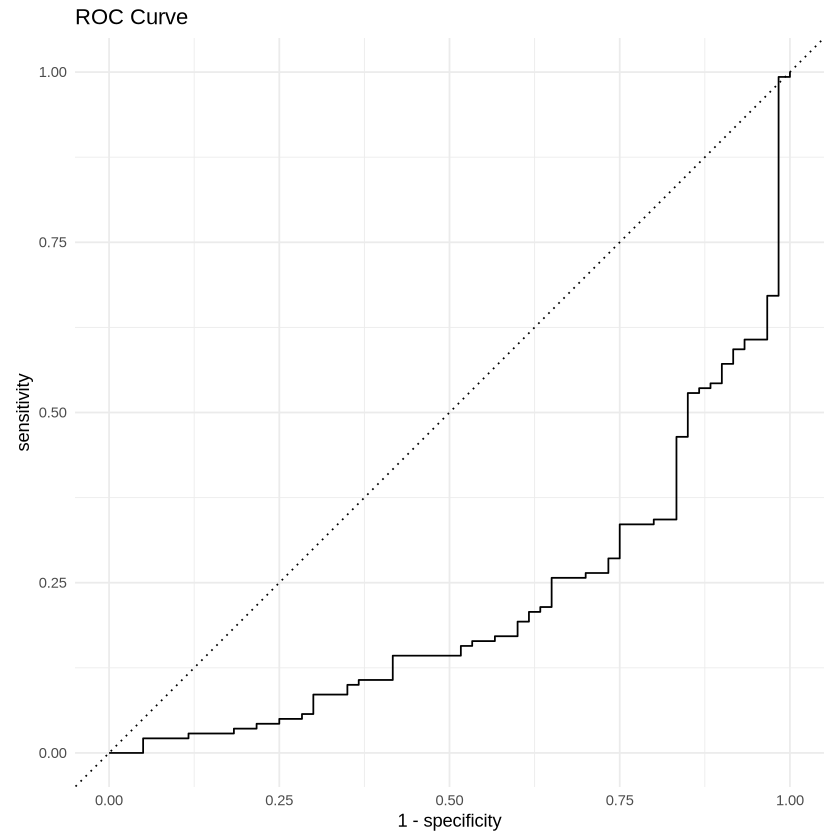

In [ ]:
library(yardstick)
library(ggplot2)

roc_df <- data.frame(
  truth = teste$Target,
  prob = prob_pos
)

roc_curve_df <- roc_curve(roc_df, truth = truth, prob)

autoplot(roc_curve_df) +
  ggtitle("ROC Curve") +
  theme_minimal()

In [75]:
library(randomForest)
set.seed(42)
rf.final <- randomForest(as.factor(Target)~., data = treino, mtry = 6)
prob_pos<- predict(rf.final, x=treino, type = "prob")[,2]

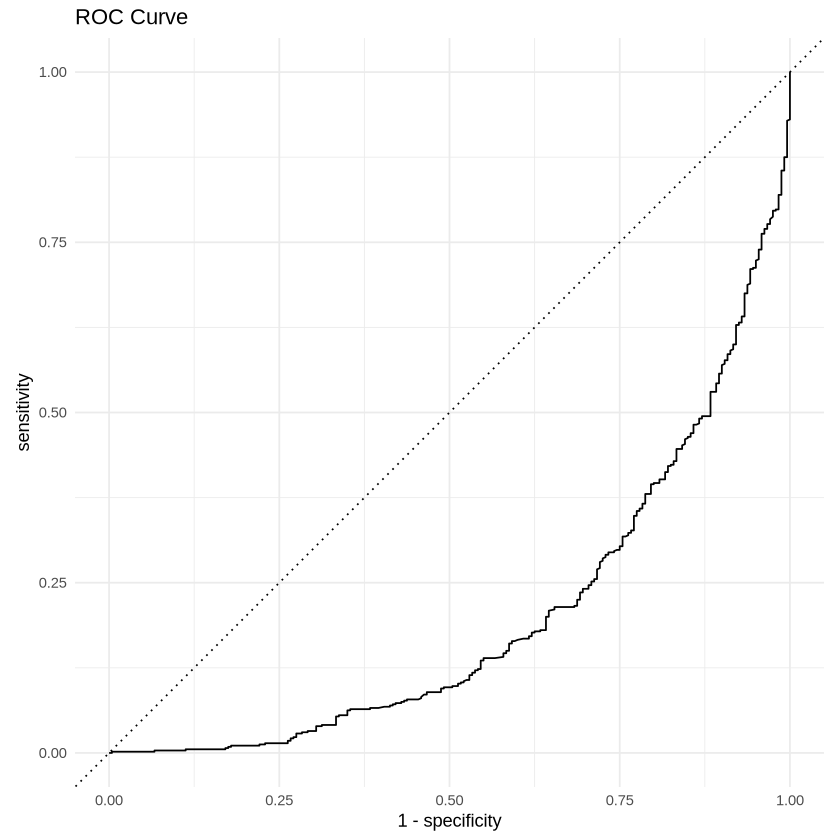

In [76]:
roc_df <- data.frame(
  truth = treino$Target,
  prob = prob_pos
)

roc_curve_df <- roc_curve(roc_df, truth = truth, prob)

autoplot(roc_curve_df) +
  ggtitle("ROC Curve") +
  theme_minimal()

[1] 0.8016034

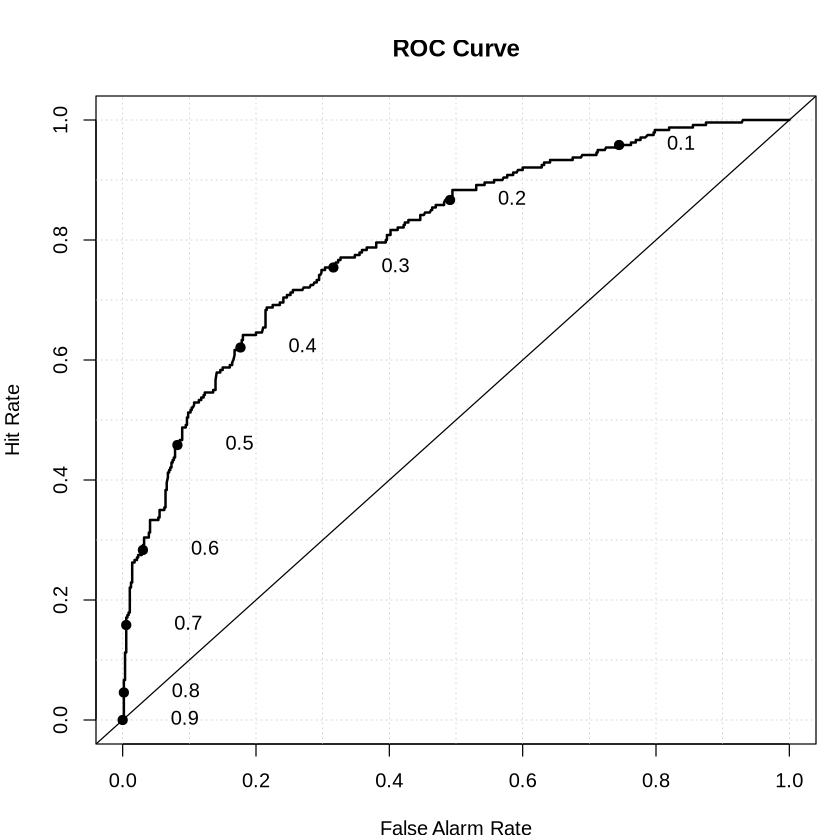

In [85]:
library(verification)
rf.final.pred<- predict(rf.final, x=treino, type = "prob")[,2]

roc.plot(as.factor(treino$Target) == "1", rf.final.pred)
roc.plot(as.factor(treino$Target) == "1", rf.final.pred)$roc.vol$Area

[1] 0.4780357

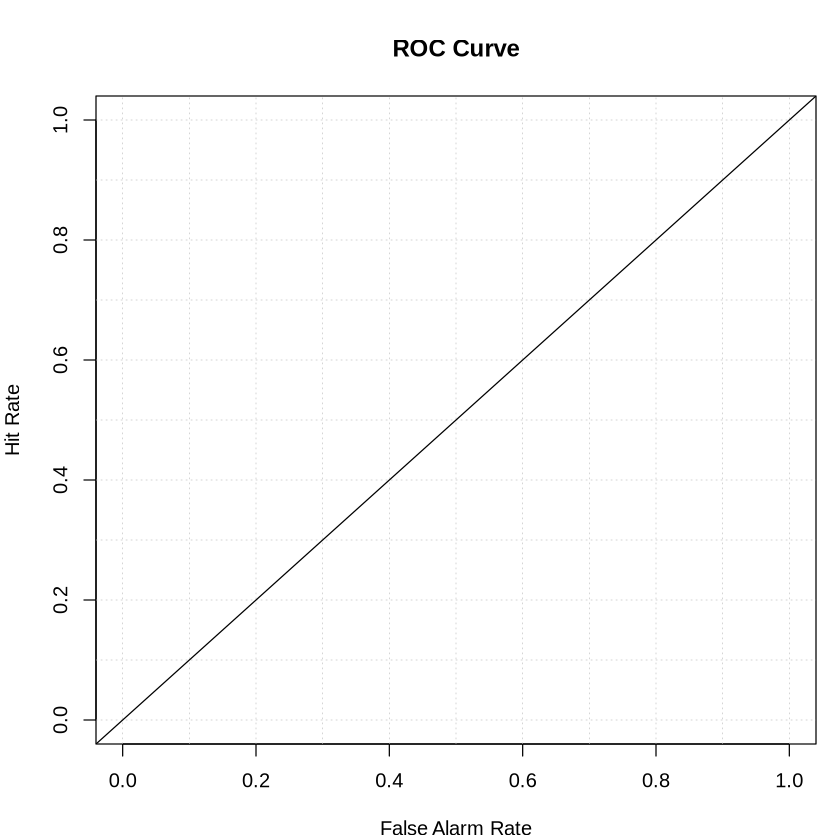

In [86]:
library(verification)
rf.final.pred<- predict(rf.final, x=teste, type = "prob")[,2]

roc.plot(as.factor(teste$Target) == "1", rf.final.pred)
roc.plot(as.factor(teste$Target) == "1", rf.final.pred)$roc.vol$Area

## 10. DATA LEAKAGE - Como NAO fazer

In [32]:
# ERRADO: scale() ANTES do split = DATA LEAKAGE!
# O scaler fica com media e desvio de TODOS os dados (incluindo teste)
# Quando aplicar no treino, ja viu informacao do teste

# dados_scaled <- scale(dados)  # USA MEDIA DO TESTE!
# split <- initial_split(dados_scaled)  # Separa depois

# CERTO: Split PRIMEIRO, preprocessamento DEPOIS
# 1. Separar treino e teste primeiro
# 2. Calcular estatisticas (media, mediana, etc) SO no treino
# 3. Aplicar no treino e teste (sem ver o teste)

cat("LEMBRETE: Split vem SEMPRE antes de qualquer transformacao!\n")
cat("scale(), mean(), median() - todos no TREINO so!\n")

LEMBRETE: Split vem SEMPRE antes de qualquer transformacao!
scale(), mean(), median() - todos no TREINO so!


In [36]:
pred <- predict(modelo, data = teste, type = "response")
pred$predictions
prob <- pred$predictions
head(prob)

[1] 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0
 [38] 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 1 1 1 1 0 0 0 0 0 0 1
 [75] 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 1 1 0 1 0 0 0 0 1 0 0 0 1
[112] 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 1 0 0 0 0 1 0 1 1 0 0 1 1
[149] 0 1 1 1 1 0 0 0 1 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0
[186] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
Levels: 0 1

[1] 0 0 0 0 0 1
Levels: 0 1

## 11. Etica: COMPAS e Vies Algoritmico

### O Caso COMPAS

**COMPAS** (Correctional Offender Management Profiling for Alternative Sanctions) e um algoritmo usado nos EUA para prever reincidencia criminal.

**ProPublica descobriu (2016):**
- **Negros:** 45% de chance de ser classificados como alto risco mesmo quando NAO reincidiram
- **Brancos:** 23% de chance

Isso acontece mesmo **controlando** para historico criminal!

### Metricas de Fairness

Quando avaliamos modelos em contextos de justica, nao basta so **accuracy**:

| Metrica | Definicao | Quando Priorizar |
|---------|-----------|------------------|
| **Precision** | TP / (TP + FP) | "Das que disse risco, quantas eram?" |
| **Recall** | TP / (TP + FN) | "Das que eram risco, quantas encontrou?" |

### Discussao

1. E justo usar um modelo que erra mais para alguns grupos?
2. Quem e responsavel quando o algoritmo erra?
3. O que podemos fazer quando um modelo e biased?

---

**Exercício:**

1. Faça uma análise semelhante a essa em outro conjunto de dados